# Estimate the Causal Impact of Marketing Campaigns

In [2]:

!pip install pycausalimpact

In [3]:
!pip install econml

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 47.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 30.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 151.9/151.9 kB 7.8 MB/s eta 0:00:00
  Attempting uninstall: shap
    Found existing installation: shap 0.51.0
    Uninstalling shap-0.51.0:
      Successfully uninstalled shap-0.51.0


In [4]:
import kagglehub
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import statsmodels.formula.api as smf
from causalimpact import CausalImpact
from econml.metalearners import TLearner
from sklearn.linear_model import LinearRegression
from econml.metalearners import XLearner
from xgboost import XGBRegressor
plt.style.use('ggplot')
sns.set_palette("husl")

# Data Set

In [5]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("manishabhatt22/marketing-campaign-performance-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'marketing-campaign-performance-dataset' dataset.
Path to dataset files: /kaggle/input/marketing-campaign-performance-dataset


In [6]:
import os
files = os.listdir(path)
print( files)

['marketing_campaign_dataset.csv']


In [7]:
import pandas as pd
df = pd.read_csv(os.path.join(path,'marketing_campaign_dataset.csv'))
df.head(3)

,Campaign_ID,Company,Campaign_Type,Target_Audience,Duration,Channel_Used,Conversion_Rate,Acquisition_Cost,ROI,Location,Language,Clicks,Impressions,Engagement_Score,Customer_Segment,Date
0,1,Innovate Industries,Email,Men 18-24,30 days,Google Ads,0.04,"$16,174.00",6.29,Chicago,Spanish,506,1922,6,Health & Wellness,2021-01-01
1,2,NexGen Systems,Email,Women 35-44,60 days,Google Ads,0.12,"$11,566.00",5.61,New York,German,116,7523,7,Fashionistas,2021-01-02
2,3,Alpha Innovations,Influencer,Men 25-34,30 days,YouTube,0.07,"$10,200.00",7.18,Los Angeles,French,584,7698,1,Outdoor Adventurers,2021-01-03


In [8]:
df.describe().round(2)

,Campaign_ID,Conversion_Rate,ROI,Clicks,Impressions,Engagement_Score
count,200000.00,200000.00,200000.00,200000.00,200000.00,200000.00
mean,100000.50,0.08,5.00,549.77,5507.30,5.49
std,57735.17,0.04,1.73,260.02,2596.86,2.87
min,1.00,0.01,2.00,100.00,1000.00,1.00
25%,50000.75,0.05,3.50,325.00,3266.00,3.00
50%,100000.50,0.08,5.01,550.00,5517.50,5.00
75%,150000.25,0.12,6.51,775.00,7753.00,8.00
max,200000.00,0.15,8.00,1000.00,10000.00,10.00


In [9]:
df['Date'] = pd.to_datetime(df['Date'])
df['Duration'] = df['Duration'].replace({'days':''}, regex=True).astype(float)
df['Acquisition_Cost'] = df['Acquisition_Cost'].replace({'\$': '', ',': ''}, regex=True).astype(float)

<>:3: SyntaxWarning: invalid escape sequence '\$'
<>:3: SyntaxWarning: invalid escape sequence '\$'
/tmp/ipykernel_2844/2694536388.py:3: SyntaxWarning: invalid escape sequence '\$'
  df['Acquisition_Cost'] = df['Acquisition_Cost'].replace({'\$': '', ',': ''}, regex=True).astype(float)


In [10]:
df.head()

,Campaign_ID,Company,Campaign_Type,Target_Audience,Duration,Channel_Used,Conversion_Rate,Acquisition_Cost,ROI,Location,Language,Clicks,Impressions,Engagement_Score,Customer_Segment,Date
0,1,Innovate Industries,Email,Men 18-24,30.0,Google Ads,0.04,16174.0,6.29,Chicago,Spanish,506,1922,6,Health & Wellness,2021-01-01
1,2,NexGen Systems,Email,Women 35-44,60.0,Google Ads,0.12,11566.0,5.61,New York,German,116,7523,7,Fashionistas,2021-01-02
2,3,Alpha Innovations,Influencer,Men 25-34,30.0,YouTube,0.07,10200.0,7.18,Los Angeles,French,584,7698,1,Outdoor Adventurers,2021-01-03
3,4,DataTech Solutions,Display,All Ages,60.0,YouTube,0.11,12724.0,5.55,Miami,Mandarin,217,1820,7,Health & Wellness,2021-01-04
4,5,NexGen Systems,Email,Men 25-34,15.0,YouTube,0.05,16452.0,6.50,Los Angeles,Mandarin,379,4201,3,Health & Wellness,2021-01-05


### EDA

In [11]:
df.dtypes

,0
Campaign_ID,int64
Company,object
Campaign_Type,object
Target_Audience,object
Duration,float64
Channel_Used,object
Conversion_Rate,float64
Acquisition_Cost,float64
ROI,float64
Location,object


In [12]:
df.isnull().sum()

,0
Campaign_ID,0
Company,0
Campaign_Type,0
Target_Audience,0
Duration,0
Channel_Used,0
Conversion_Rate,0
Acquisition_Cost,0
ROI,0
Location,0


In [13]:
df['Company'].value_counts()

,count
Company,
TechCorp,40237
Alpha Innovations,40051
DataTech Solutions,40012
NexGen Systems,39991
Innovate Industries,39709


In [14]:
df['Campaign_Type'].value_counts()

,count
Campaign_Type,
Influencer,40169
Search,40157
Display,39987
Email,39870
Social Media,39817


In [15]:
df['Duration'].value_counts()

,count
Duration,
30.0,50255
45.0,50100
60.0,49866
15.0,49779


In [16]:
df['Customer_Segment'].value_counts()

,count
Customer_Segment,
Foodies,40208
Tech Enthusiasts,40151
Outdoor Adventurers,40011
Health & Wellness,39888
Fashionistas,39742


In [17]:
df['Date'].value_counts().sort_index()

,count
Date,
2021-01-01,548
2021-01-02,548
2021-01-03,548
2021-01-04,548
2021-01-05,548
...,...
2021-12-27,547
2021-12-28,547
2021-12-29,547


In [18]:
df['Location'].value_counts()

,count
Location,
Miami,40269
New York,40024
Chicago,40010
Los Angeles,39947
Houston,39750


In [19]:
df['ROI'].value_counts()

,count
ROI,
7.43,407
4.25,383
6.05,378
5.89,375
7.69,374
...,...
6.38,282
7.09,280
6.99,274


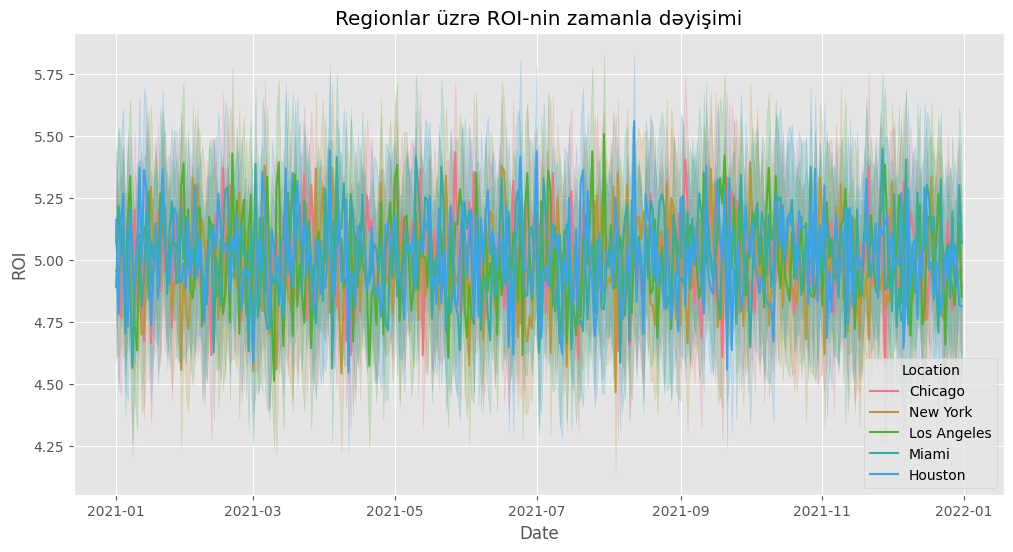

In [20]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x='Date', y='ROI', hue='Location')
plt.title('Regionlar üzrə ROI-nin zamanla dəyişimi')
plt.show()

In [21]:
ts_data = df.groupby(['Date', 'Location'])['ROI'].mean().sort_values(ascending=False)
ts_data.head(3)

,,ROI
Date,Location,
2021-08-12,Houston,5.558130
2021-07-30,Los Angeles,5.506449
2021-11-27,Miami,5.448496


## Visualizations

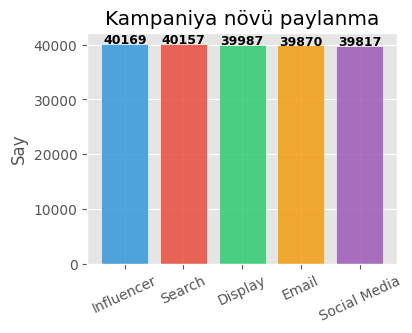

In [22]:
fig, ax = plt.subplots(figsize=(4, 3))

ct_counts = df['Campaign_Type'].value_counts()

bars = ax.bar(ct_counts.index,
              ct_counts.values,
              color=['#3498DB','#E74C3C','#2ECC71','#F39C12','#9B59B6'], alpha=0.85, edgecolor='white')
ax.set_title('Kampaniya növü paylanma')
ax.set_ylabel('Say')
ax.tick_params(axis='x', rotation=25)
for bar in bars:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+5,
            str(bar.get_height()), ha='center', fontsize=9, fontweight='bold')

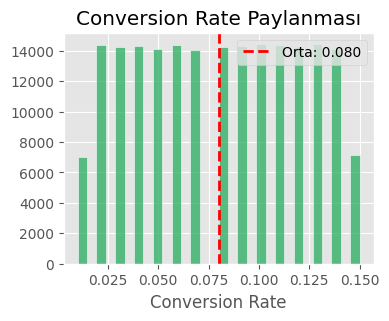

In [23]:
fig, ax = plt.subplots(figsize=(4, 3))
ax.hist(df['Conversion_Rate'], bins=30, color='#27AE60', alpha=0.75, edgecolor='white')
ax.axvline(df['Conversion_Rate'].mean(), color='red', ls='--', lw=2,
           label=f'Orta: {df["Conversion_Rate"].mean():.3f}')
ax.set_title('Conversion Rate Paylanması')
ax.set_xlabel('Conversion Rate'); ax.legend()


Text(0.5, 0, 'Clicks')

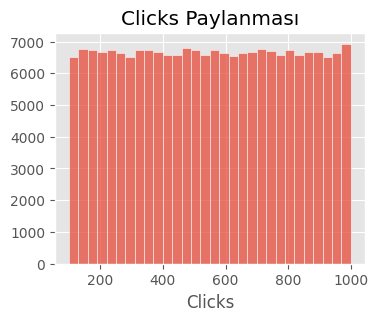

In [24]:
fig, ax = plt.subplots(figsize=(4, 3))
ax.hist(df['Clicks'], bins=30, color='#E74C3C', alpha=0.75, edgecolor='white')
ax.set_title('Clicks Paylanması')
ax.set_xlabel('Clicks')


Text(0.5, 0, 'Orta Conversion Rate')

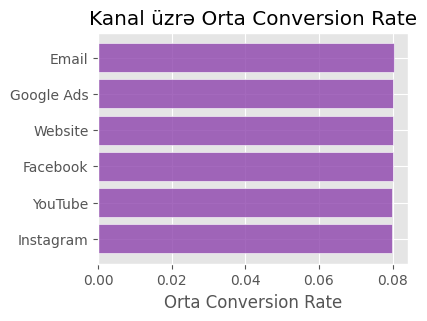

In [25]:
fig, ax = plt.subplots(figsize=(4, 3))
ch_cr = df.groupby('Channel_Used')['Conversion_Rate'].mean().sort_values(ascending=True)
ax.barh(ch_cr.index,ch_cr.values, color='#8E44AD', alpha=0.8, edgecolor='white')
ax.set_title('Kanal üzrə Orta Conversion Rate')
ax.set_xlabel('Orta Conversion Rate')

Text(0, 0.5, 'Orta Clicks')

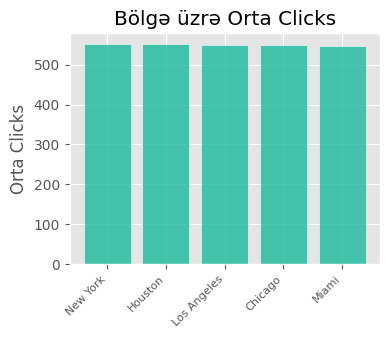

In [26]:
fig, ax = plt.subplots(figsize=(4, 3))
loc_clicks = df.groupby('Location')['Clicks'].mean().sort_values(ascending=False)
ax.bar(range(len(loc_clicks)), loc_clicks.values, color='#1ABC9C', alpha=0.8, edgecolor='white')
ax.set_xticks(range(len(loc_clicks)))
ax.set_xticklabels(loc_clicks.index, rotation=45, ha='right', fontsize=8)
ax.set_title('Bölgə üzrə Orta Clicks')
ax.set_ylabel('Orta Clicks')

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


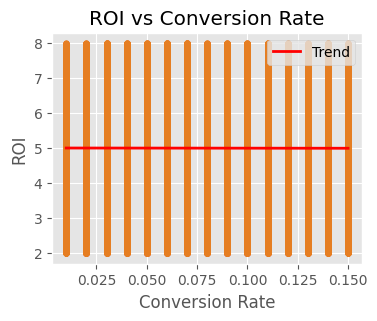

In [27]:
fig, ax = plt.subplots(figsize=(4, 3))
ax.scatter(df['Conversion_Rate'], df['ROI'],
           alpha=0.3, color='#E67E22', s=15)
# Trend xətti
z = np.polyfit(df['Conversion_Rate'], df['ROI'], 1)
p = np.poly1d(z)
x_line = np.linspace(df['Conversion_Rate'].min(), df['Conversion_Rate'].max(), 100)
ax.plot(x_line, p(x_line), 'r-', lw=2, label='Trend')
ax.set_title('ROI vs Conversion Rate')
ax.set_xlabel('Conversion Rate'); ax.set_ylabel('ROI')
ax.legend()

## Target Defining

In [28]:


df['Sales'] = df['Clicks'] * df['Conversion_Rate'] * 50

day_of_year = df['Date'].dt.dayofyear
df['Seasonal'] = 1 + 0.1 * np.sin(2 * np.pi * day_of_year / 365)  # 10% seasonal

df['Sales'] = (df['Sales'] * df['Seasonal']).round(2)

In [29]:
df['Sales'].describe().round(2).to_string()

'count    200000.00\nmean       2201.05\nstd        1627.03\nmin          45.01\n25%         882.92\n50%        1780.94\n75%        3192.78\nmax        8247.99'

In [30]:
df.groupby('Campaign_Type')['Sales'].mean().round(2).to_string()

'Campaign_Type\nDisplay         2204.18\nEmail           2189.76\nInfluencer      2204.10\nSearch          2197.49\nSocial Media    2209.72'

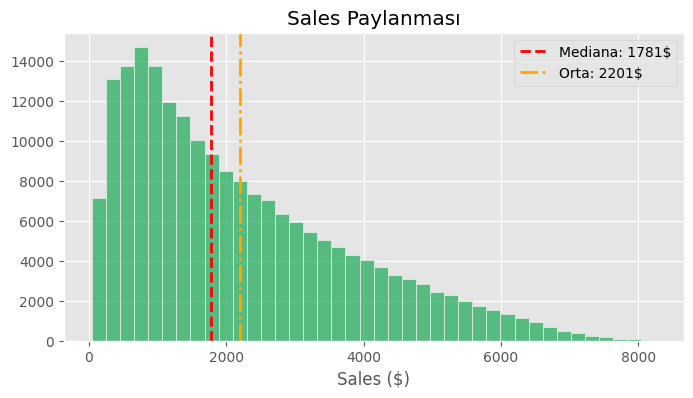

In [31]:
fig, ax = plt.subplots( figsize=(8, 4))
ax.hist(df['Sales'], bins=40, color='#27AE60', alpha=0.75, edgecolor='white')
ax.axvline(df['Sales'].median(), color='red', ls='--', lw=2, label=f'Mediana: {df["Sales"].median():.0f}$')
ax.axvline(df['Sales'].mean(),   color='orange', ls='-.',  lw=2, label=f'Orta: {df["Sales"].mean():.0f}$')
ax.set_title('Sales Paylanması'); ax.set_xlabel('Sales ($)'); ax.legend()

Text(0, 0.5, 'Sales ($)')

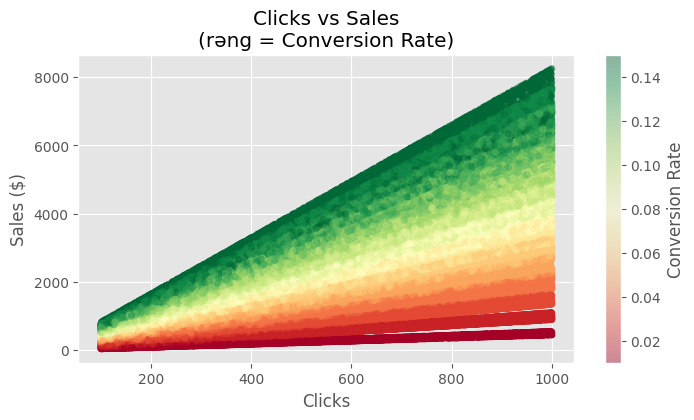

In [32]:
fig, ax = plt.subplots( figsize=(8, 4))
scatter = ax.scatter(df['Clicks'], df['Sales'],
                     c=df['Conversion_Rate'], cmap='RdYlGn',
                     alpha=0.4, s=20)
plt.colorbar(scatter, ax=ax, label='Conversion Rate')
ax.set_title('Clicks vs Sales\n(rəng = Conversion Rate)')
ax.set_xlabel('Clicks'); ax.set_ylabel('Sales ($)')


## Treatment and Control Groups

In [33]:
loc_engagement = df.groupby('Location')['Campaign_Type'].count()
print(loc_engagement.sort_values(ascending=False))


Location
Miami          40269
New York       40024
Chicago        40010
Los Angeles    39947
Houston        39750
Name: Campaign_Type, dtype: int64


In [34]:

threshold = loc_engagement.median()

n = len(loc_engagement)

treatment_locs = loc_engagement.iloc[:n//2].index
control_locs   = loc_engagement.iloc[n//2:].index
print(f'Treatment {sorted(treatment_locs)}')
print(f'Control {sorted(control_locs)}')

Treatment ['Chicago', 'Houston']
Control ['Los Angeles', 'Miami', 'New York']


In [35]:
df['Group']   = df['Location'].apply(
    lambda x: 'Treatment' if x in treatment_locs else 'Control'
)
df['Treated'] = (df['Group'] == 'Treatment').astype(int)
print(df['Group'].value_counts())

Group
Control      120240
Treatment     79760
Name: count, dtype: int64


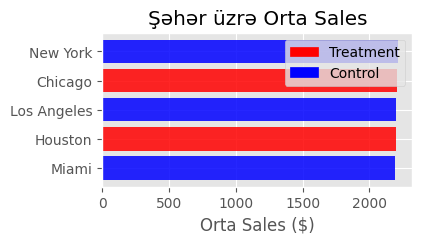

In [36]:
fig, ax = plt.subplots(figsize=(4, 2))

city_sales = (
    df.groupby(['Location', 'Group'])['Sales'].mean().reset_index().sort_values('Sales'))

colors = city_sales['Group'].map({'Treatment': 'red','Control': 'blue'})
ax.barh(city_sales['Location'], city_sales['Sales'],color=colors, alpha=0.85)
ax.set(title='Şəhər üzrə Orta Sales',
       xlabel='Orta Sales ($)')
ax.legend(handles=[
  mpatches.Patch(color='red', label='Treatment'),mpatches.Patch(color='blue', label='Control')])

/tmp/ipykernel_2844/3177484547.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([t_sales, c_sales],labels=['Treatment', 'Control'],patch_artist=True,medianprops=dict(color='black', lw=2))


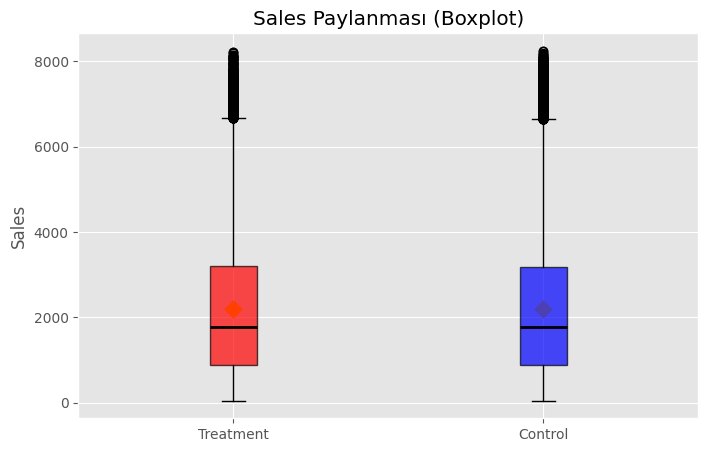

In [37]:
fig, ax = plt.subplots(figsize=(8, 5))
t_sales = df[df['Treated'] == 1]['Sales']
c_sales = df[df['Treated'] == 0]['Sales']

bp = ax.boxplot([t_sales, c_sales],labels=['Treatment', 'Control'],patch_artist=True,medianprops=dict(color='black', lw=2))
colors = ['red', 'blue']
for box, color in zip(bp['boxes'], colors):
  box.set_facecolor(color)
  box.set_alpha(0.7)

ax.set(title='Sales Paylanması (Boxplot)',ylabel='Sales')
means = [t_sales.mean(), c_sales.mean()]
for i, mean in enumerate(means, 1):
    ax.scatter(i, mean, color='gold', s=80, marker='D',label='Orta' if i == 1 else '')


### Time Periods

In [38]:
start= pd.Timestamp('2021-07-01')

df['Post']   = (df['Date'] >= start).astype(int)
df['Period'] = df['Post'].map({0: 'Pre', 1: 'Post'})

In [39]:
mask_treated_post = (df['Treated'] == 1) & (df['Post'] == 1)
df[mask_treated_post].head()

,Campaign_ID,Company,Campaign_Type,Target_Audience,Duration,Channel_Used,Conversion_Rate,Acquisition_Cost,ROI,Location,...,Impressions,Engagement_Score,Customer_Segment,Date,Sales,Seasonal,Group,Treated,Post,Period
183,184,DataTech Solutions,Social Media,Men 18-24,45.0,Email,0.06,12315.0,3.97,Chicago,...,4099,7,Fashionistas,2021-07-03,1511.09,0.997418,Treatment,1,1,Post
184,185,NexGen Systems,Influencer,Men 25-34,15.0,Instagram,0.14,17598.0,7.27,Chicago,...,8475,7,Outdoor Adventurers,2021-07-04,6698.06,0.995698,Treatment,1,1,Post
185,186,TechCorp,Email,Women 35-44,30.0,Instagram,0.05,19545.0,2.57,Houston,...,1917,1,Health & Wellness,2021-07-05,519.35,0.993979,Treatment,1,1,Post
186,187,NexGen Systems,Email,Men 25-34,60.0,Email,0.13,14231.0,6.28,Chicago,...,8509,3,Health & Wellness,2021-07-06,2012.31,0.992261,Treatment,1,1,Post
187,188,Alpha Innovations,Influencer,Women 25-34,30.0,Instagram,0.11,15162.0,7.80,Chicago,...,6030,8,Tech Enthusiasts,2021-07-07,1961.28,0.990546,Treatment,1,1,Post


In [40]:
TRUE_LIFT_PCT = 0.12

days_since = (df.loc[mask_treated_post, 'Date'] - start).dt.days
ramp = np.minimum(1.0, days_since / 30)  # 30 gündə tam güc

df['Sales_with_effect'] = df['Sales'].copy()
df.loc[mask_treated_post, 'Sales_with_effect'] = (
    df.loc[mask_treated_post, 'Sales'] * (1 + TRUE_LIFT_PCT * ramp)
)
df['Sales']=df['Sales_with_effect']

In [41]:
summary = df.groupby(['Group','Period'])['Sales'].mean().unstack('Period')
print('\nOrta Sales (qrup × dövr):')
print(summary.round(2).to_string())


Orta Sales (qrup × dövr):
Period        Post      Pre
Group                      
Control    2060.10  2344.66
Treatment  2288.84  2340.35


In [42]:
delta_t = summary.loc['Treatment','Post'] - summary.loc['Treatment','Pre']
delta_c = summary.loc['Control','Post']   - summary.loc['Control','Pre']
did_naive = delta_t - delta_c
print(f'\nTreatment:{delta_t:+.2f}')
print(f'Control: {delta_c:+.2f}')
print(f'DiD:  {did_naive:+.2f}')


Treatment:-51.51
Control: -284.56
DiD:  +233.05


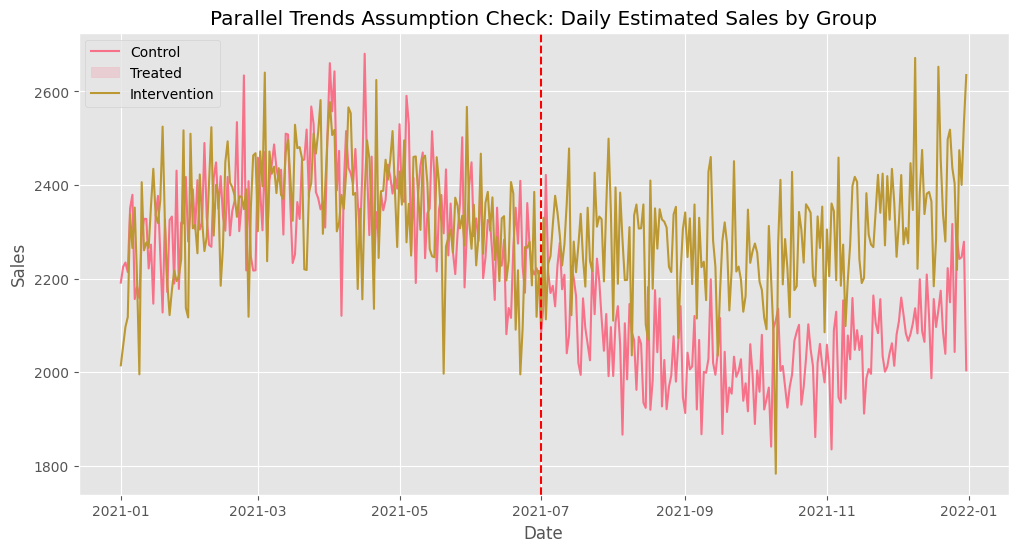

In [43]:
daily_sales = df.groupby(['Date', 'Treated'])['Sales'].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(data=daily_sales, x='Date', y='Sales', hue='Treated')
plt.axvline(x=start, color='red', linestyle='--', label='Campaign Launch')
plt.title('Parallel Trends Assumption Check: Daily Estimated Sales by Group')
plt.legend(['Control', 'Treated', 'Intervention'])
plt.show()

### Data Prepearing

In [44]:
df['Date'] = pd.to_datetime(df['Date'])

df['YearMonth'] = df['Date'].dt.to_period('M')
df['Post'] = (df['Date'] >= '2021-07-01').astype(int)
# aylıq panel data yaradılması DiD üçün lazımdır
df['Week'] = df['Date'].dt.to_period('W')
#df['Month_num'] = df['Date'].dt.month  # 1-12

panel = (
    df.groupby(['YearMonth', 'Group', 'Treated', 'Post'])
    .agg(
        Sales           = ('Sales', 'mean'),
        Conversion_Rate = ('Conversion_Rate', 'mean'),
        Clicks          = ('Clicks', 'mean'),
        ROI             = ('ROI', 'mean'),
        n               = ('Sales', 'count'),).reset_index())
panel['Month_num'] = panel['YearMonth'].dt.month

panel_t = panel[panel['Group']=='Treatment'].sort_values('Month_num')
panel_c = panel[panel['Group']=='Control'].sort_values('Month_num')

print(panel[['YearMonth','Group','Post','Sales']].to_string(index=False))

YearMonth     Group  Post       Sales
  2021-01   Control     0 2271.126700
  2021-01 Treatment     0 2256.265776
  2021-02   Control     0 2354.535515
  2021-02 Treatment     0 2354.832347
  2021-03   Control     0 2405.148388
  2021-03 Treatment     0 2422.243127
  2021-04   Control     0 2415.265997
  2021-04 Treatment     0 2395.290328
  2021-05   Control     0 2360.179322
  2021-05 Treatment     0 2345.346568
  2021-06   Control     0 2262.764260
  2021-06 Treatment     0 2267.948499
  2021-07   Control     1 2144.023496
  2021-07 Treatment     1 2286.798927
  2021-08   Control     1 2033.077545
  2021-08 Treatment     1 2262.784734
  2021-09   Control     1 2001.324638
  2021-09 Treatment     1 2252.420183
  2021-10   Control     1 2002.800126
  2021-10 Treatment     1 2231.698838
  2021-11   Control     1 2041.184545
  2021-11 Treatment     1 2308.629224
  2021-12   Control     1 2135.165470
  2021-12 Treatment     1 2391.651172


## Paralel Trend Visual

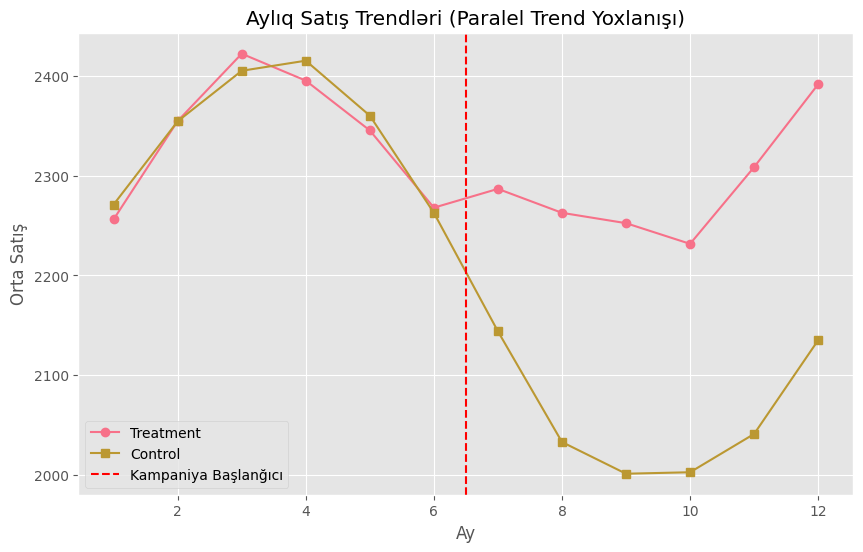

In [45]:
plt.figure(figsize=(10, 6))

plt.plot(panel_t['Month_num'], panel_t['Sales'], label='Treatment', marker='o')

plt.plot(panel_c['Month_num'], panel_c['Sales'], label='Control', marker='s')

plt.axvline(x=panel[panel['Post']==1]['Month_num'].min() - 0.5, color='red', linestyle='--', label='Kampaniya Başlanğıcı')
plt.title('Aylıq Satış Trendləri (Paralel Trend Yoxlanışı)')
plt.xlabel('Ay')
plt.ylabel('Orta Satış')
plt.legend()
plt.grid(True)
plt.show()

In [46]:
pre_t = panel_t[panel_t['Post'] == 0].sort_values('Month_num')
pre_c = panel_c[panel_c['Post'] == 0].sort_values('Month_num')

slope_t, int_t = np.polyfit(pre_t['Month_num'], pre_t['Sales'], 1)
slope_c, int_c = np.polyfit(pre_c['Month_num'], pre_c['Sales'], 1)
pre_gap = pre_t['Sales'].mean() - pre_c['Sales'].mean()
print(f'\nTreatment (slope):  {slope_t:.3f} $/ay')
print(f'Control (slope):    {slope_c:.3f} $/ay')
print(f'Slope fərqi (mütləq):            {abs(slope_t-slope_c):.3f}')
print(f'orta fərq (fixed gap): {pre_gap:.2f}$')




Treatment (slope):  0.086 $/ay
Control (slope):    -0.422 $/ay
Slope fərqi (mütləq):            0.508
orta fərq (fixed gap): -4.52$


## Difference in Difference Model

In [47]:
panel['did'] = panel['Treated'] * panel['Post']

# OLS Reqressiya modeli
model = smf.ols('Sales ~ Treated + Post + did', data=panel).fit(
    cov_type='cluster',
    cov_kwds={'groups': panel['Group']}
)

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.804
Model:                            OLS   Adj. R-squared:                  0.774
Method:                 Least Squares   F-statistic:                 6.966e+28
Date:                Mon, 04 May 2026   Prob (F-statistic):           2.68e-15
Time:                        19:49:21   Log-Likelihood:                -131.41
No. Observations:                  24   AIC:                             270.8
Df Residuals:                      20   BIC:                             275.5
Df Model:                           3                                         
Covariance Type:              cluster                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   2344.8367   2.99e-12   7.85e+14      0.0

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 3, but rank is 2
  warnings.warn('covariance of constraints does not have full '


## Causal Impact


[Timestamp('2021-01-01 00:00:00'), Timestamp('2021-06-01 00:00:00')]
[Timestamp('2021-07-01 00:00:00'), Timestamp('2021-12-01 00:00:00')]


/usr/local/lib/python3.12/dist-packages/causalimpact/main.py:603: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  if not data.applymap(np.isreal).values.all():
/usr/local/lib/python3.12/dist-packages/causalimpact/main.py:302: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  self.mu_sig = (mu[0], sig[0])
/usr/local/lib/python3.12/dist-packages/statsmodels/base/optimizer.py:21: FutureWarning: Keyword arguments have been passed to the optimizer that have no effect. The list of allowed keyword arguments for method lbfgs is: m, pgtol, factr, maxfun, epsilon, approx_grad, bounds, loglike_and_score, iprint. The list of unsupported keyword arguments passed include: nseasons, standardize. After release 0.14, this will raise.
  warnings.warn(
/usr/local/lib/python3.12/dist-packa

Posterior Inference {Causal Impact}
                          Average            Cumulative
Actual                    2289.0             13733.98
Prediction (s.d.)         2054.15 (8.25)     12324.91 (49.51)
95% CI                    [2038.22, 2070.56] [12229.3, 12423.36]

Absolute effect (s.d.)    234.84 (8.25)      1409.07 (49.51)
95% CI                    [218.44, 250.78]   [1310.62, 1504.69]

Relative effect (s.d.)    11.43% (0.4%)      11.43% (0.4%)
95% CI                    [10.63%, 12.21%]   [10.63%, 12.21%]

Posterior tail-area probability p: 0.0
Posterior prob. of a causal effect: 100.0%

For more details run the command: print(impact.summary('report'))


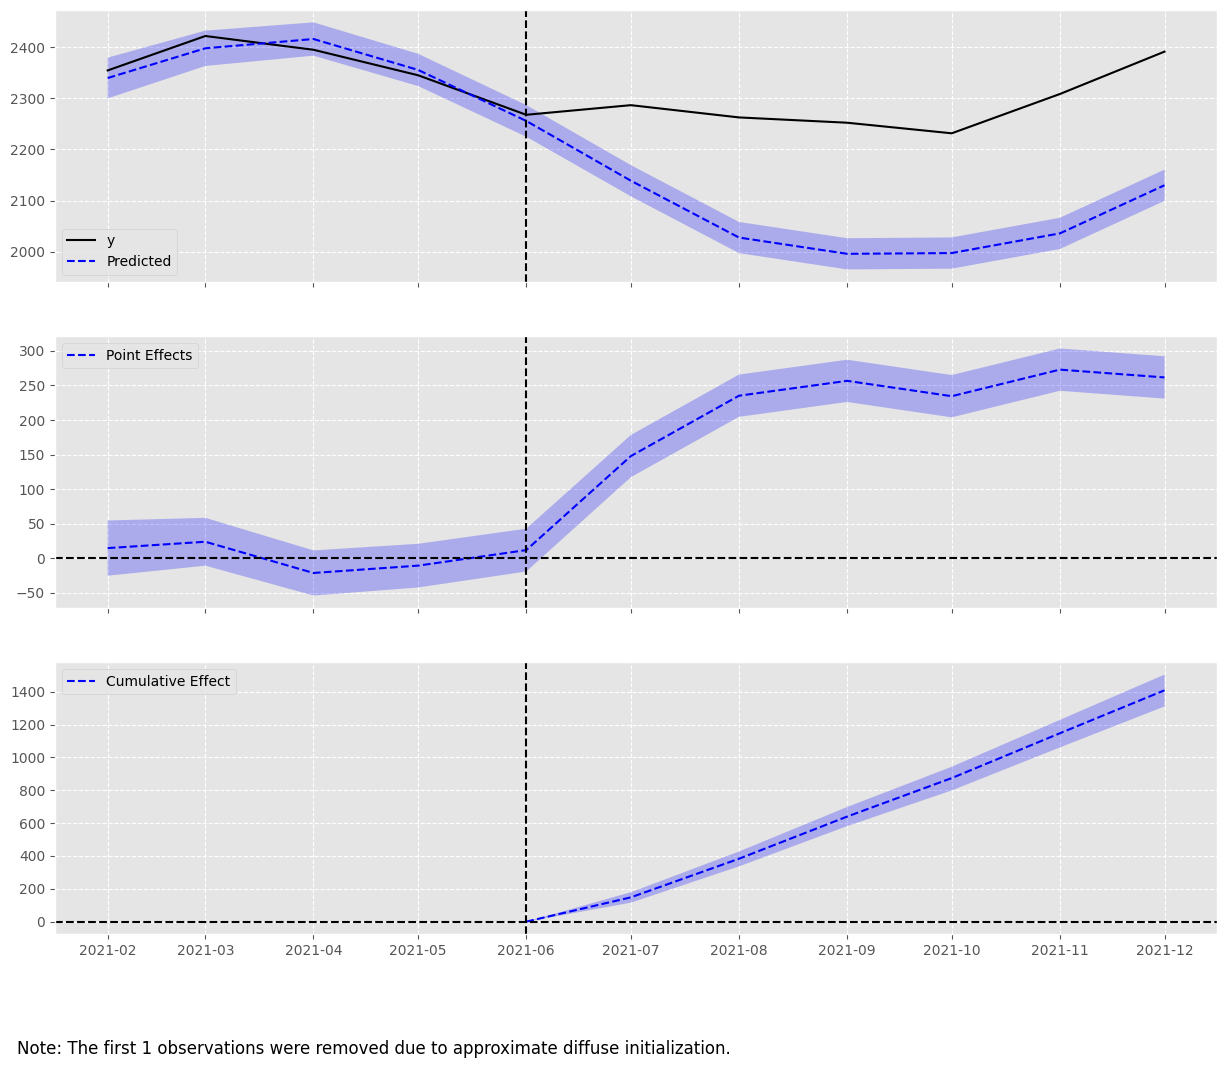

In [48]:
ci_data = panel.pivot(index='YearMonth', columns='Group', values='Sales')
ci_data = ci_data[['Treatment', 'Control']]

ci_data.index = ci_data.index.to_timestamp()
ci_data = ci_data.dropna().sort_index()

cutoff = pd.Timestamp('2021-07-01')

pre_end = ci_data.index[ci_data.index < cutoff].max()
post_start = ci_data.index[ci_data.index >= cutoff].min()

pre = [ci_data.index.min(), pre_end]
post = [post_start, ci_data.index.max()]

print(pre)
print(post)

ci = CausalImpact(ci_data, pre, post)

print(ci.summary())
ci.plot()

In [49]:
att = model.params['did']
print(f"ATT (Real Kampaniya Təsiri): {att:.2f}")

ATT (Real Kampaniya Təsiri): 233.92


In [50]:
# EconML üçün
from econml.metalearners import SLearner, TLearner, XLearner
from econml.dml import LinearDML

from sklearn.ensemble import GradientBoostingRegressor

Y_post = df['Sales'].values

T_post = df['Treated'].values

features = ['Clicks','Impressions','Duration']
X_data =df[features].values

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_data)

## EconML

In [51]:
# Modellər
estimators = {
    'S-Learner': SLearner(overall_model=GradientBoostingRegressor(random_state=42)),
    'T-Learner': TLearner(models=GradientBoostingRegressor(random_state=42)),
    'X-Learner': XLearner(models=GradientBoostingRegressor(random_state=42)),
    'DML': LinearDML(model_y=GradientBoostingRegressor(), model_t=GradientBoostingRegressor())
}

# Modellərin fit edilməsi və CATE
models_cate = {}
for name, est in estimators.items():
    est.fit(Y_post, T_post, X=X_scaled)
    models_cate[name] = est.effect(X_scaled)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


In [52]:
print(f" {name:15s} ATE :")
for name, cate in models_cate.items():
    print(f"   {name}: {cate.mean():.2f} ± {cate.std():.2f}")


 DML             ATE :
   S-Learner: 106.69 ± 54.42
   T-Learner: 110.96 ± 91.66
   X-Learner: 110.86 ± 74.55
   DML: 110.79 ± 51.79


### Learners Visualization

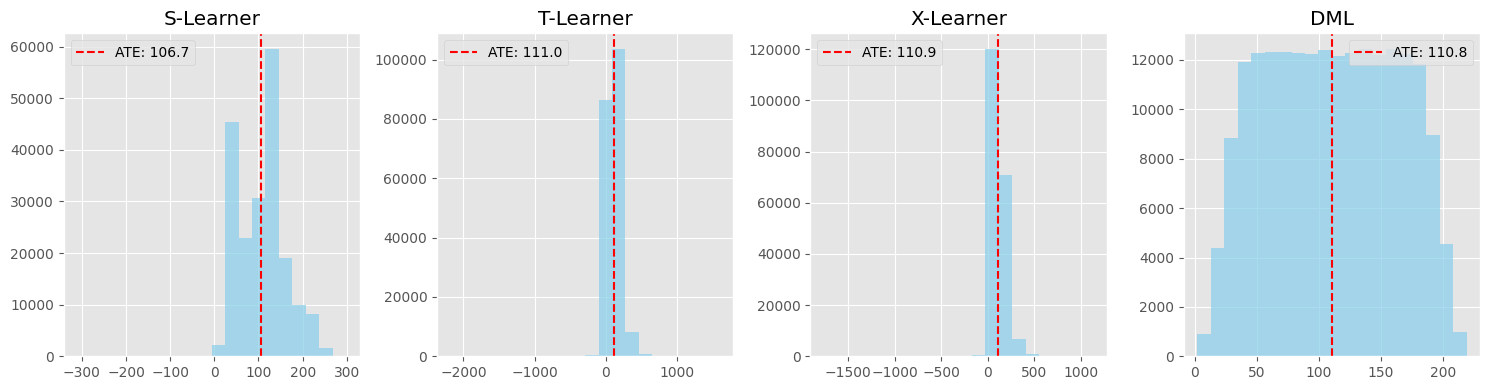

In [53]:
fig, axes = plt.subplots(1, len(models_cate), figsize=(15, 4))

for ax, (name, cate) in zip(axes, models_cate.items()):
    ax.hist(cate, bins=20, color='skyblue', alpha=0.7)
    ax.axvline(cate.mean(), color='red', linestyle='--', label=f'ATE: {cate.mean():.1f}')
    ax.set_title(name)
    ax.legend()

plt.tight_layout()
plt.show()

X-Learner qrafikində sağ tərəfdəki (200-dən yuxarı) müştərilər sizin xeyirli müştərilərinizdir yeni
kampaniyaya ən çox reaksiya verənlərdir.



In [54]:
def calculate_segment_did(df, segment_col):
    # Bütün qrupların ortalaması
    means = df.groupby([segment_col, 'Treated', 'Post'])['Sales'].mean().unstack(level=[1, 2])


    did = (means[1, 1] - means[1, 0]) - (means[0, 1] - means[0, 0])
    pct = (did / means[0, 0]) * 100

    return pd.DataFrame({'did_vahid': did, 'did_faiz': pct})

customer_results = calculate_segment_did(df, 'Customer_Segment')
channel_results = calculate_segment_did(df, 'Channel_Used')

print(customer_results)

                      did_vahid   did_faiz
Customer_Segment                          
Fashionistas         253.908551  10.774986
Foodies              184.043094   7.859394
Health & Wellness    211.737996   9.036735
Outdoor Adventurers  273.254567  11.562583
Tech Enthusiasts     242.760083  10.467146


In [55]:
print(customer_results.sort_values(by='did_faiz', ascending=False))

                      did_vahid   did_faiz
Customer_Segment                          
Outdoor Adventurers  273.254567  11.562583
Fashionistas         253.908551  10.774986
Tech Enthusiasts     242.760083  10.467146
Health & Wellness    211.737996   9.036735
Foodies              184.043094   7.859394


In [56]:
print(channel_results)

               did_vahid   did_faiz
Channel_Used                       
Email         186.538497   7.951466
Facebook      194.126044   8.253467
Google Ads    297.044048  12.710881
Instagram     259.540124  11.067733
Website       231.591725   9.812532
YouTube       229.454309   9.856172


In [57]:
print(channel_results.sort_values(by='did_faiz', ascending=False))

               did_vahid   did_faiz
Channel_Used                       
Google Ads    297.044048  12.710881
Instagram     259.540124  11.067733
YouTube       229.454309   9.856172
Website       231.591725   9.812532
Facebook      194.126044   8.253467
Email         186.538497   7.951466


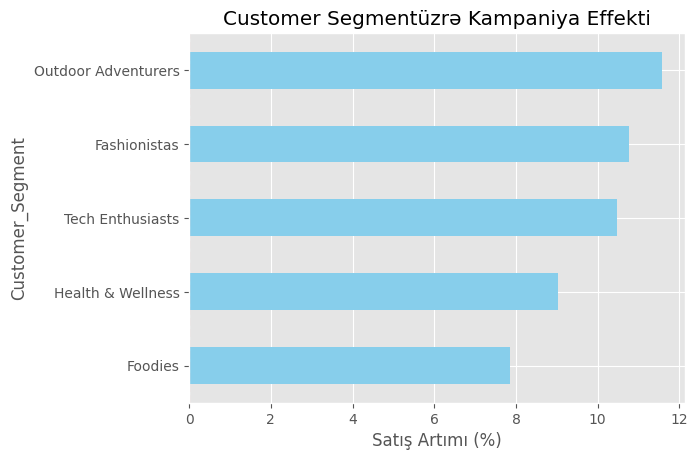

In [58]:
import matplotlib.pyplot as plt

def plot_did_effect(results):
    results['did_faiz'].sort_values().plot(kind='barh', color='skyblue')
    plt.axvline(0, color='red', linestyle='--', alpha=0.5)
    plt.title("Customer Segmentüzrə Kampaniya Effekti")
    plt.xlabel("Satış Artımı (%)")
    plt.show()

plot_did_effect(customer_results)

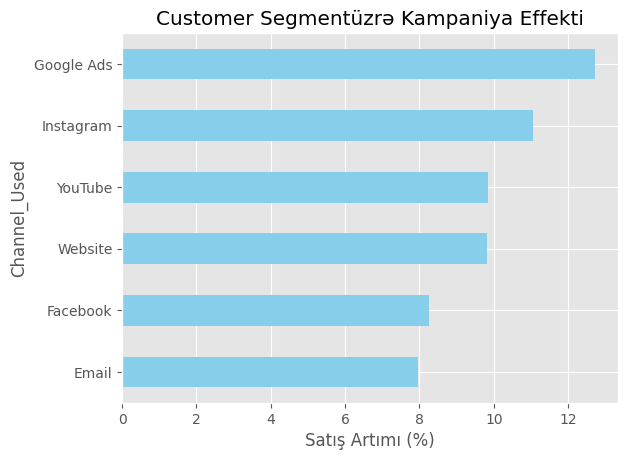

In [59]:
plot_did_effect(channel_results)

## Bootstrap

In [60]:
def get_did_pct(data):
    res = data.groupby(['Treated', 'Post'])['Sales'].mean()
    # (Treated_Post - Treated_Pre) - (Control_Post - Control_Pre)
    did = (res[1, 1] - res[1, 0]) - (res[0, 1] - res[0, 0])
    return (did / res[0, 0]) * 100

In [61]:
itera = 500
Locations = df['Location'].unique()
boot_results = []

for i in range(itera):
    sampled_stores = np.random.choice(Locations, size=len(Locations), replace=True)
    temp_df = pd.concat([df[df['Location'] == s] for s in sampled_stores])

    try:
        boot_results.append(get_did_pct(temp_df))
    except:
        continue

In [62]:
#Confidence Interval
ci_low = np.percentile(boot_results, 2.5)
ci_high = np.percentile(boot_results, 97.5)
avg_effect = np.mean(boot_results)

print(f"Orta Artım: {avg_effect:.2f}%")
print(f"95% bu araliqda olar: [{ci_low:.2f}%, {ci_high:.2f}%]")

if ci_low > 0:
    print("etibarlıdır")
else:
    print(" təsadüfi ola bilər.")

Orta Artım: 9.97%
95% bu araliqda olar: [8.90%, 11.14%]
etibarlıdır


### nəticənin stabilliyini yoxlamaq üçün Cluster Bootstrap metodundan istifadə etdim